<a href="https://colab.research.google.com/github/Aditya-Deshpande19/Yoga-pose-detection/blob/main/yogaposedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

# Paths
TRAIN_PATH = "/content/drive/My Drive/train"
VALID_PATH = "/content/drive/My Drive/valid"
TEST_PATH = "/content/drive/My Drive/test"

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Unable to read {image_path}")
        return None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    if not results.pose_landmarks:
        # No pose detected, return None
        return None

    keypoints = []
    for lm in results.pose_landmarks.landmark:
        keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
    return keypoints  # Length: 33 landmarks * 4 = 132 features

def load_data(path):
    X = []
    y = []
    labels = sorted(os.listdir(path))
    print(f"Found classes: {labels}")
    for label in labels:
        class_folder = os.path.join(path, label)
        if not os.path.isdir(class_folder):
            continue
        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            keypoints = extract_keypoints(img_path)
            if keypoints is not None:
                X.append(keypoints)
                y.append(label)
    return np.array(X), np.array(y), labels

print("Extracting train data keypoints...")
X_train, y_train, class_names = load_data(TRAIN_PATH)

print("Extracting validation data keypoints...")
X_valid, y_valid, _ = load_data(VALID_PATH)

print("Extracting test data keypoints...")
X_test, y_test, _ = load_data(TEST_PATH)

print(f"Train samples: {len(X_train)}, Valid samples: {len(X_valid)}, Test samples: {len(X_test)}")

# Encode labels to integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc = le.transform(y_test)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train_enc)

# Validation accuracy
valid_preds = clf.predict(X_valid)
print("Validation Accuracy:", accuracy_score(y_valid_enc, valid_preds))

# Test accuracy
test_preds = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test_enc, test_preds))

# Save model and label encoder
with open('yoga_pose_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model and label encoder saved.")


Extracting train data keypoints...
Found classes: ['Akarna_Dhanurasana', 'Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 'Boat_Pose_or_Paripurna_Navasana_', 'Bound_Angle_Pose_or_Baddha_Konasana_', 'Bow_Pose_or_Dhanurasana_', 'Bridge_Pose_or_Setu_Bandha_Sarvangasana_', 'Camel_Pose_or_Ustrasana_', 'Cat_Cow_Pose_or_Marjaryasana_', 'Chair_Pose_or_Utkatasana_', 'Child_Pose_or_Balasana_', 'Cobra_Pose_or_Bhujangasana_', 'Cockerel_Pose', 'Corpse_Pose_or_Savasana_', 'Cow_Face_Pose_or_Gomukhasana_', 'Crane_(Crow)_Pose_or_Bakasana_', 'Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_', 'Dolphin_Pose_or_Ardha_Pincha_Mayurasana_', 'Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_', 'Eagle_Pose_or_Garudasana_', 'Eight-Angle_Pose_or_Astavakrasana_', 'Extended_Puppy_Pose_or_Uttana_Shishosana_', 'Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_', 'Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_', 'Feathered_Peacock_Pose_or_Pincha_Mayurasana_', 'Firefly_Pose_or_Tittibhasana_', 'Fish

In [ ]:
# Save training data for reuse
joblib.dump(X_train, 'X_train.pkl')
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_test, 'y_train.pkl')
joblib.dump(y_test, 'y_test.pkl')

['y_test.pkl']

In [ ]:
# 📦 Install dependencies if not done
# pip install mediapipe scikit-learn matplotlib seaborn opencv-python skl2onnx joblib

import os
import cv2
import numpy as np
import joblib
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# === Load Classifier & Encoder ===
clf = joblib.load('yoga_pose_classifier.pkl')          # Random Forest
le = joblib.load('label_encoder.pkl')                  # LabelEncoder
X_train = joblib.load('X_train.pkl')                   # Save these during training
X_test = joblib.load('X_test.pkl')
y_test = joblib.load('y_test.pkl')

# === MediaPipe Setup ===
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils

# === STEP 1: Single Image Visualization ===
def plot_prediction(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Invalid image path.")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = pose.process(img_rgb)

    if results.pose_landmarks:
        landmarks = [coord for lm in results.pose_landmarks.landmark for coord in (lm.x, lm.y, lm.z)]
        pred = clf.predict([landmarks])[0]
        label = le.inverse_transform([pred])[0]
        mp_drawing.draw_landmarks(img_rgb, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
        plt.imshow(img_rgb)
        plt.title(f'Prediction: {label}', fontsize=14)
        plt.axis('off')
        plt.show()
    else:
        print("No pose detected.")

# Example usage
# plot_prediction('/content/drive/MyDrive/test/Tree_Pose_or_Vrksasana_/Tree_Pose_or_Vrksasana__image_123.jpg')


# === STEP 2: Confusion Matrix ===
def show_confusion_matrix():
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(16, 16))
    disp.plot(ax=ax, xticks_rotation='vertical')
    plt.title("Confusion Matrix", fontsize=18)
    plt.grid(False)
    plt.show()

# Example usage
# show_confusion_matrix()


# === STEP 3: Convert Model to ONNX ===
def convert_to_onnx(model, X_sample):
    initial_type = [('float_input', FloatTensorType([None, len(X_sample[0])]))]
    onnx_model = convert_sklearn(model, initial_types=initial_type)
    with open("yoga_pose_classifier.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())
    print("✅ Model converted and saved as yoga_pose_classifier.onnx")

# Example usage
# convert_to_onnx(clf, X_train)


# === STEP 4: Real-Time Pose Classification ===
def run_realtime_pose():
    cap = cv2.VideoCapture(0)
    realtime_pose = mp_pose.Pose()
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = realtime_pose.process(img_rgb)

        if result.pose_landmarks:
            keypoints = [coord for lm in result.pose_landmarks.landmark for coord in (lm.x, lm.y, lm.z)]
            if len(keypoints) == len(X_train[0]):
                pred = clf.predict([keypoints])[0]
                label = le.inverse_transform([pred])[0]
                cv2.putText(frame, f'{label}', (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)

            mp_drawing.draw_landmarks(frame, result.pose_landmarks, mp_pose.POSE_CONNECTIONS)

        cv2.imshow('Yoga Pose Detector', frame)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Example usage
# run_realtime_pose()


In [ ]:
from google.colab import files
import cv2
import numpy as np
import joblib

# Load your trained model and label encoder
clf = joblib.load('yoga_pose_classifier.pkl')
le = joblib.load('label_encoder.pkl')

# Function to extract keypoints from a single image (replace with your keypoint extraction method)
def extract_keypoints_from_image(image_path):
    import mediapipe as mp
    import cv2
    import numpy as np

    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(static_image_mode=True)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = pose.process(img_rgb)

    if not results.pose_landmarks:
        raise ValueError("No pose landmarks detected in the image")

    landmarks = results.pose_landmarks.landmark
    keypoints = []
    for lm in landmarks:
        keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])

    keypoints = np.array(keypoints).reshape(1, -1)  # shape (1, 132)
    pose.close()
    return keypoints


# Step 1: Upload file using dialog
uploaded = files.upload()

# There might be multiple files, take the first one
image_path = list(uploaded.keys())[0]

print(f"Uploaded file: {image_path}")

# Step 2: Extract keypoints/features from the uploaded image
X_single = extract_keypoints_from_image(image_path)

# Step 3: Predict pose class
y_pred_single = clf.predict(X_single)
pose_predicted = le.inverse_transform(y_pred_single)

print(f"Predicted Yoga Pose: {pose_predicted[0]}")


Saving Screenshot 2025-05-30 013153.png to Screenshot 2025-05-30 013153.png
Uploaded file: Screenshot 2025-05-30 013153.png
Predicted Yoga Pose: Standing_big_toe_hold_pose_or_Utthita_Padangusthasana


Saving Screenshot 2025-05-30 013331.png to Screenshot 2025-05-30 013331.png
Pose landmarks drawn and saved as output_pose.png


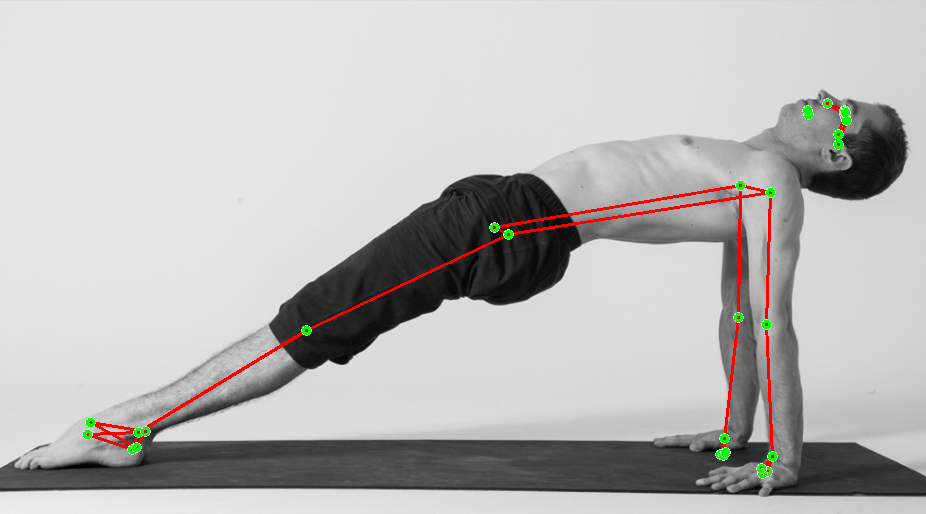

In [ ]:
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
from IPython.display import Image, display

def draw_pose_landmarks(image_array):
    mp_pose = mp.solutions.pose
    mp_drawing = mp.solutions.drawing_utils

    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        results = pose.process(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
        if not results.pose_landmarks:
            print("No pose landmarks detected.")
            return None

        mp_drawing.draw_landmarks(
            image_array, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
            mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))
        return image_array

# Upload image file
uploaded = files.upload()

for filename in uploaded.keys():
    # Read uploaded file as numpy array
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    # Draw pose landmarks
    img_with_landmarks = draw_pose_landmarks(img)

    if img_with_landmarks is not None:
        # Save output image
        output_path = "output_pose.png"
        cv2.imwrite(output_path, img_with_landmarks)

        print(f"Pose landmarks drawn and saved as {output_path}")
        # Display output image in notebook
        display(Image(output_path))


Saving Screenshot 2025-05-30 013331.png to Screenshot 2025-05-30 013331 (2).png
Detected Pose: Upward_Plank_Pose_or_Purvottanasana_


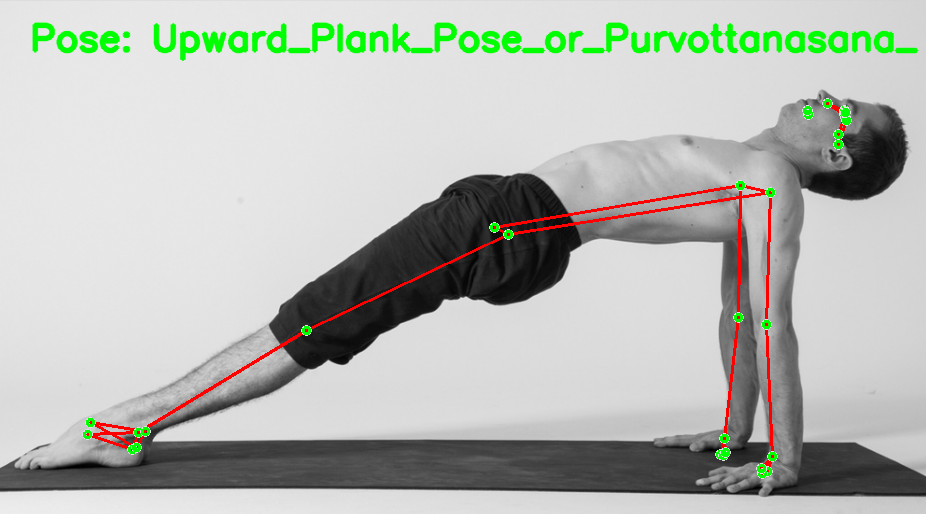

In [ ]:
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
import pickle
from IPython.display import Image, display

# Load your trained model and label encoder
with open('yoga_pose_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints(image_array):
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        image_rgb = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        if not results.pose_landmarks:
            return None
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints).reshape(1, -1), results.pose_landmarks

def draw_pose_landmarks(image_array, landmarks):
    mp_drawing.draw_landmarks(
        image_array, landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))

# Upload image file
uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    # Extract keypoints and pose landmarks
    keypoints, landmarks = extract_keypoints(img)

    if keypoints is None:
        print("No pose detected in the image.")
        cv2.imwrite("output_pose.png", img)
        display(Image("output_pose.png"))
        continue

    # Predict the pose label
    pred_label_idx = clf.predict(keypoints)[0]
    pred_label = le.inverse_transform([pred_label_idx])[0]

    # Draw landmarks
    draw_pose_landmarks(img, landmarks)

    # Put text label on the image
    cv2.putText(img, f"Pose: {pred_label}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0, 255, 0), 3, cv2.LINE_AA)

    # Save and display
    output_path = "output_pose.png"
    cv2.imwrite(output_path, img)

    print(f"Detected Pose: {pred_label}")
    display(Image(output_path))


In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp
import pickle
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Paths (update the new data folder)
NEW_DATA_PATH = "/content/drive/My Drive/train"  # new images folder organized by class subfolders
OLD_X_PATH = "X_train.pkl"     # previously saved old features
OLD_Y_PATH = "y_train.pkl"     # previously saved old labels
MODEL_PATH = "yoga_pose_classifier_updated.pkl"
LABEL_ENCODER_PATH = "label_encoder_updated.pkl"

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not read image {image_path}")
        return None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    if not results.pose_landmarks:
        return None
    keypoints = []
    for lm in results.pose_landmarks.landmark:
        keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
    if len(keypoints) != 132:  # 33 landmarks * 4
        return None
    return keypoints

def load_new_data(path):
    X_new = []
    y_new = []
    labels = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    print(f"New data classes found: {labels}")
    for label in labels:
        class_folder = os.path.join(path, label)
        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            keypoints = extract_keypoints(img_path)
            if keypoints is not None:
                X_new.append(keypoints)
                y_new.append(label)
    return np.array(X_new), np.array(y_new)

# Load old training data
print("Loading old training data...")
X_old = joblib.load(OLD_X_PATH)
y_old = joblib.load(OLD_Y_PATH)

# Load new training data
print("Extracting keypoints from new data...")
X_new, y_new = load_new_data(NEW_DATA_PATH)

print(f"Old data samples: {len(X_old)}, New data samples: {len(X_new)}")

# Combine old and new
X_combined = np.concatenate((X_old, X_new), axis=0)
y_combined = np.concatenate((y_old, y_new), axis=0)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_combined)

# Train new model
print("Training new RandomForestClassifier on combined data...")
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_combined, y_encoded)

# Save updated model and label encoder
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(clf, f)

with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(le, f)

print(f"Updated model saved to {MODEL_PATH}")
print(f"Updated label encoder saved to {LABEL_ENCODER_PATH}")


Loading old training data...
Extracting keypoints from new data...
New data classes found: ['Akarna_Dhanurasana', 'Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 'Boat_Pose_or_Paripurna_Navasana_', 'Bound_Angle_Pose_or_Baddha_Konasana_', 'Bow_Pose_or_Dhanurasana_', 'Bridge_Pose_or_Setu_Bandha_Sarvangasana_', 'Camel_Pose_or_Ustrasana_', 'Cat_Cow_Pose_or_Marjaryasana_', 'Chair_Pose_or_Utkatasana_', 'Child_Pose_or_Balasana_', 'Cobra_Pose_or_Bhujangasana_', 'Cockerel_Pose', 'Corpse_Pose_or_Savasana_', 'Cow_Face_Pose_or_Gomukhasana_', 'Crane_(Crow)_Pose_or_Bakasana_', 'Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_', 'Dolphin_Pose_or_Ardha_Pincha_Mayurasana_', 'Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_', 'Eagle_Pose_or_Garudasana_', 'Eight-Angle_Pose_or_Astavakrasana_', 'Extended_Puppy_Pose_or_Uttana_Shishosana_', 'Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_', 'Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_', 'Feathered_Peacock_Pose_or_Pincha_Mayurasana_

ValueError: Found input variables with inconsistent numbers of samples: [20658, 11890]

In [ ]:
import tensorflow as tf

# Suppose `model` is your trained Keras model
model.save('yoga_pose_classifier.pkl')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save tflite model
with open('pose_classifier.tflite', 'wb') as f:
    f.write(tflite_model)


NameError: name 'model' is not defined

In [ ]:
!pip install mediapipe

In [ ]:
  import os
  import cv2
  import numpy as np
  import mediapipe as mp
  import torch
  import torch.nn as nn
  import torch.optim as optim
  from sklearn.preprocessing import LabelEncoder
  from sklearn.metrics import accuracy_score
  from torch.utils.data import Dataset, DataLoader
  import pickle

  # === CONFIGURATION ===
  TRAIN_PATH = "/content/drive/My Drive/train"
  VALID_PATH = "/content/drive/My Drive/valid"
  TEST_PATH  = "/content/drive/My Drive/test"
  IMAGE_SIZE = (256, 256)  # Resize to 256x256

  # === MEDIA PIPE ===
  mp_pose = mp.solutions.pose
  pose_detector = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

  def extract_keypoints(image_path):
      image = cv2.imread(image_path)
      if image is None:
          print(f"Warning: Unable to read {image_path}")
          return None
      image = cv2.resize(image, IMAGE_SIZE)
      image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      results = pose_detector.process(image_rgb)
      if not results.pose_landmarks:
          return None
      keypoints = []
      for lm in results.pose_landmarks.landmark:
          keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
      return keypoints  # 33 landmarks * 4 = 132

  def load_data(path):
      X, y = [], []
      labels = sorted(os.listdir(path))
      print(f"Found classes: {labels}")
      for label in labels:
          class_folder = os.path.join(path, label)
          if not os.path.isdir(class_folder):
              continue
          for file in os.listdir(class_folder):
              img_path = os.path.join(class_folder, file)
              keypoints = extract_keypoints(img_path)
              if keypoints:
                  X.append(keypoints)
                  y.append(label)
      return np.array(X, dtype=np.float32), np.array(y), labels

  # === LOAD DATA ===
  print("Loading training data...")
  X_train, y_train, class_names = load_data(TRAIN_PATH)
  print("Loading validation data...")
  X_valid, y_valid, _ = load_data(VALID_PATH)
  print("Loading test data...")
  X_test, y_test, _ = load_data(TEST_PATH)

  # === LABEL ENCODING ===
  le = LabelEncoder()
  y_train_enc = le.fit_transform(y_train)
  y_valid_enc = le.transform(y_valid)
  y_test_enc  = le.transform(y_test)
  num_classes = len(le.classes_)

  # Save label encoder
  with open('label_encoder.pkl', 'wb') as f:
      pickle.dump(le, f)

  # === PYTORCH DATASETS ===
  class PoseDataset(Dataset):
      def __init__(self, X, y):
          self.X = torch.tensor(X, dtype=torch.float32)
          self.y = torch.tensor(y, dtype=torch.long)
      def __len__(self): return len(self.X)
      def __getitem__(self, idx): return self.X[idx], self.y[idx]

  train_loader = DataLoader(PoseDataset(X_train, y_train_enc), batch_size=32, shuffle=True)
  valid_loader = DataLoader(PoseDataset(X_valid, y_valid_enc), batch_size=32)
  test_loader  = DataLoader(PoseDataset(X_test, y_test_enc), batch_size=32)

  # === MODEL DEFINITION ===
  class PoseClassifier(nn.Module):
      def __init__(self, input_dim=132, hidden1=256, hidden2=128, output_dim=num_classes):
          super().__init__()
          self.net = nn.Sequential(
              nn.Linear(input_dim, hidden1),
              nn.ReLU(),
              nn.Dropout(0.3),
              nn.Linear(hidden1, hidden2),
              nn.ReLU(),
              nn.Dropout(0.3),
              nn.Linear(hidden2, output_dim)
          )
      def forward(self, x): return self.net(x)

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = PoseClassifier().to(device)
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  loss_fn = nn.CrossEntropyLoss()

  print("Training...")
  epochs = 25
  for epoch in range(epochs):
      model.train()
      running_loss = 0.0
      for Xb, yb in train_loader:
          Xb, yb = Xb.to(device), yb.to(device)
          optimizer.zero_grad()
          preds = model(Xb)
          loss = loss_fn(preds, yb)
          loss.backward()
          optimizer.step()
          running_loss += loss.item()
      print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

      # Validation Accuracy
      model.eval()
      y_preds, y_true = [], []
      with torch.no_grad():
          for Xv, yv in valid_loader:
              Xv, yv = Xv.to(device), yv.to(device)
              preds = model(Xv)
              y_preds.extend(torch.argmax(preds, 1).cpu().numpy())
              y_true.extend(yv.cpu().numpy())
      acc = accuracy_score(y_true, y_preds)
      print(f"Validation Accuracy: {acc:.4f}")

  # === TEST ACCURACY ===
  model.eval()
  y_preds, y_true = [], []
  with torch.no_grad():
      for Xt, yt in test_loader:
          Xt, yt = Xt.to(device), yt.to(device)
          preds = model(Xt)
          y_preds.extend(torch.argmax(preds, 1).cpu().numpy())
          y_true.extend(yt.cpu().numpy())
  test_acc = accuracy_score(y_true, y_preds)
  print(f"Test Accuracy: {test_acc:.4f}")

  # === SAVE MODELS ===
  torch.save(model.state_dict(), "pose_classifier.pth")
  print("PyTorch model saved: pose_classifier.pth")

  # Optional TorchScript for Android
  example_input = torch.rand(1, 132).to(device)
  scripted_model = torch.jit.trace(model, example_input)
  scripted_model.save("pose_classifier_scripted.pt")
  print("TorchScript model saved: pose_classifier_scripted.pt")


Loading training data...
Found classes: ['Akarna_Dhanurasana', 'Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 'Boat_Pose_or_Paripurna_Navasana_', 'Bound_Angle_Pose_or_Baddha_Konasana_', 'Bow_Pose_or_Dhanurasana_', 'Bridge_Pose_or_Setu_Bandha_Sarvangasana_', 'Camel_Pose_or_Ustrasana_', 'Cat_Cow_Pose_or_Marjaryasana_', 'Chair_Pose_or_Utkatasana_', 'Child_Pose_or_Balasana_', 'Cobra_Pose_or_Bhujangasana_', 'Cockerel_Pose', 'Corpse_Pose_or_Savasana_', 'Cow_Face_Pose_or_Gomukhasana_', 'Crane_(Crow)_Pose_or_Bakasana_', 'Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_', 'Dolphin_Pose_or_Ardha_Pincha_Mayurasana_', 'Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_', 'Eagle_Pose_or_Garudasana_', 'Eight-Angle_Pose_or_Astavakrasana_', 'Extended_Puppy_Pose_or_Uttana_Shishosana_', 'Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_', 'Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_', 'Feathered_Peacock_Pose_or_Pincha_Mayurasana_', 'Firefly_Pose_or_Tittibhasana_', 'Fish_Pose_or_M

KeyboardInterrupt: 

In [ ]:
import torch
from torch.utils.mobile_optimizer import optimize_for_mobile

# Move model to CPU
model.cpu()
model.eval()

# Create example input on CPU
example_input = torch.rand(1, 3, 224, 224)

# Trace the model
traced_script_module = torch.jit.trace(model, example_input)

# Optimize for mobile
optimized_traced_model = optimize_for_mobile(traced_script_module)

# Save the optimized model
optimized_traced_model._save_for_lite_interpreter("vgg19.pt")

NameError: name 'model' is not defined

In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
import pickle

# === MOUNT DRIVE (if needed) ===
from google.colab import drive
drive.mount('/content/drive')

# === CONFIGURATION ===
TRAIN_PATH = "/content/drive/MyDrive/archive 8/dataset/train"
TEST_PATH  = "/content/drive/MyDrive/archive 8/dataset/test"
IMAGE_SIZE = (256, 256)

# === MEDIA PIPE ===
mp_pose = mp.solutions.pose
pose_detector = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Unable to read {image_path}")
        return None
    image = cv2.resize(image, IMAGE_SIZE)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose_detector.process(image_rgb)
    if not results.pose_landmarks:
        return None
    keypoints = []
    for lm in results.pose_landmarks.landmark:
        keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
    return keypoints  # 33 landmarks * 4 = 132

def load_data(path):
    X, y = [], []
    labels = sorted(os.listdir(path))
    print(f"Found classes: {labels}")
    for label in labels:
        class_folder = os.path.join(path, label)
        if not os.path.isdir(class_folder):
            continue
        for file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, file)
            keypoints = extract_keypoints(img_path)
            if keypoints:
                X.append(keypoints)
                y.append(label)
    return np.array(X, dtype=np.float32), np.array(y), labels

# === LOAD DATA ===
print("Loading training data...")
X_train, y_train, class_names = load_data(TRAIN_PATH)
print("Loading test data...")
X_test, y_test, _ = load_data(TEST_PATH)

# === SPLIT VALIDATION FROM TRAIN ===
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# === LABEL ENCODING ===
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc  = le.transform(y_test)
num_classes = len(le.classes_)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# === PYTORCH DATASETS ===
class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(PoseDataset(X_train, y_train_enc), batch_size=32, shuffle=True)
valid_loader = DataLoader(PoseDataset(X_valid, y_valid_enc), batch_size=32)
test_loader  = DataLoader(PoseDataset(X_test, y_test_enc), batch_size=32)

# === MODEL ===
class PoseClassifier(nn.Module):
    def __init__(self, input_dim=132, hidden1=256, hidden2=128, output_dim=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden2, output_dim)
        )
    def forward(self, x): return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# === TRAINING ===
print("Training...")
epochs = 25
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(Xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    y_preds, y_true = [], []
    with torch.no_grad():
        for Xv, yv in valid_loader:
            Xv, yv = Xv.to(device), yv.to(device)
            preds = model(Xv)
            y_preds.extend(torch.argmax(preds, 1).cpu().numpy())
            y_true.extend(yv.cpu().numpy())
    acc = accuracy_score(y_true, y_preds)
    print(f"Validation Accuracy: {acc:.4f}")

# === TEST ACCURACY ===
model.eval()
y_preds, y_true = [], []
with torch.no_grad():
    for Xt, yt in test_loader:
        Xt, yt = Xt.to(device), yt.to(device)
        preds = model(Xt)
        y_preds.extend(torch.argmax(preds, 1).cpu().numpy())
        y_true.extend(yt.cpu().numpy())
test_acc = accuracy_score(y_true, y_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# === SAVE MODEL ===
torch.save(model.state_dict(), "pose_classifier.pth")
print("PyTorch model saved: pose_classifier.pth")

# === EXPORT TO TORCHSCRIPT (OPTIONAL) ===
example_input = torch.rand(1, 132).to(device)
scripted_model = torch.jit.trace(model, example_input)
scripted_model.save("pose_classifier_scripted.pt")
print("TorchScript model saved: pose_classifier_scripted.pt")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading training data...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/archive 8/dataset/train'

In [ ]:
# === SETUP ===
import os
import cv2
import numpy as np
import mediapipe as mp
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
import zipfile
import pickle

# === EXTRACT ZIP FILE ===
zip_path = "/content/drive/MyDrive/archive (8).zip"
extract_to = "/content/dataset"

if not os.path.exists(extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Dataset extracted to:", extract_to)
else:
    print("Dataset already extracted")

# === DETECT PATH ===
# Look for train/ and test/ folders automatically
def find_subfolder_path(base_path, target):
    for root, dirs, files in os.walk(base_path):
        for d in dirs:
            if d.lower() == target.lower():
                return os.path.join(root, d)
    return None

TRAIN_PATH = find_subfolder_path(extract_to, "train")
TEST_PATH = find_subfolder_path(extract_to, "test")

if not TRAIN_PATH or not TEST_PATH:
    raise FileNotFoundError("Could not find 'train' or 'test' folders inside extracted dataset.")

print(f"TRAIN_PATH: {TRAIN_PATH}")
print(f"TEST_PATH : {TEST_PATH}")

IMAGE_SIZE = (256, 256)

mp_pose = mp.solutions.pose
pose_detector = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Unable to read {image_path}")
        return None
    image = cv2.resize(image, IMAGE_SIZE)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose_detector.process(image_rgb)
    if not results.pose_landmarks:
        return None
    keypoints = []
    for lm in results.pose_landmarks.landmark:
        keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
    return keypoints

def load_data(path):
    X, y = [], []
    labels = sorted(os.listdir(path))
    print(f"Found classes: {labels}")
    for label in labels:
        class_folder = os.path.join(path, label)
        if not os.path.isdir(class_folder):
            continue
        for file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, file)
            keypoints = extract_keypoints(img_path)
            if keypoints:
                X.append(keypoints)
                y.append(label)
    return np.array(X, dtype=np.float32), np.array(y), labels

print("Loading training data...")
X_train, y_train, class_names = load_data(TRAIN_PATH)
print("Loading test data...")
X_test, y_test, _ = load_data(TEST_PATH)


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)


with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)


class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(PoseDataset(X_train, y_train_enc), batch_size=32, shuffle=True)
test_loader = DataLoader(PoseDataset(X_test, y_test_enc), batch_size=32)


class PoseClassifier(nn.Module):
    def __init__(self, input_dim=132, hidden1=256, hidden2=128, output_dim=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden2, output_dim)
        )
    def forward(self, x): return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

print("Training model...")
epochs = 25
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(Xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


print("Evaluating on test set...")
model.eval()
y_preds, y_true = [], []
with torch.no_grad():
    for Xt, yt in test_loader:
        Xt, yt = Xt.to(device), yt.to(device)
        preds = model(Xt)
        y_preds.extend(torch.argmax(preds, 1).cpu().numpy())
        y_true.extend(yt.cpu().numpy())
test_acc = accuracy_score(y_true, y_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# === SAVE MODELS ===
torch.save(model.state_dict(), "pose_classifier.pth")
print("PyTorch model saved: pose_classifier.pth")

# Optional: TorchScript for mobile/Android
example_input = torch.rand(1, 132).to(device)
scripted_model = torch.jit.trace(model, example_input)
scripted_model.save("pose_classifier_scripted.pt")
print("TorchScript model saved: pose_classifier_scripted.pt")


Dataset already extracted
TRAIN_PATH: /content/dataset/DATASET/TRAIN
TEST_PATH : /content/dataset/DATASET/TEST
Loading training data...
Found classes: ['downdog', 'goddess', 'plank', 'tree', 'warrior2']
Loading test data...
Found classes: ['downdog', 'goddess', 'plank', 'tree', 'warrior2']
Training model...
Epoch 1/25, Loss: 1.4328
Epoch 2/25, Loss: 1.0392
Epoch 3/25, Loss: 0.9302
Epoch 4/25, Loss: 0.8347
Epoch 5/25, Loss: 0.7654
Epoch 6/25, Loss: 0.6778
Epoch 7/25, Loss: 0.6497
Epoch 8/25, Loss: 0.5933
Epoch 9/25, Loss: 0.5370
Epoch 10/25, Loss: 0.5321
Epoch 11/25, Loss: 0.4761
Epoch 12/25, Loss: 0.4506
Epoch 13/25, Loss: 0.4559
Epoch 14/25, Loss: 0.4177
Epoch 15/25, Loss: 0.3918
Epoch 16/25, Loss: 0.3925
Epoch 17/25, Loss: 0.3515
Epoch 18/25, Loss: 0.3689
Epoch 19/25, Loss: 0.3698
Epoch 20/25, Loss: 0.3335
Epoch 21/25, Loss: 0.3192
Epoch 22/25, Loss: 0.3243
Epoch 23/25, Loss: 0.3024
Epoch 24/25, Loss: 0.3027
Epoch 25/25, Loss: 0.3210
Evaluating on test set...
Test Accuracy: 0.9500
Py

In [ ]:
import torch
import cv2
import numpy as np

# Load the TorchScript model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.jit.load("pose_classifier_scripted.pt").to(device)
model.eval()

# Load label encoder
import pickle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# MediaPipe pose setup (same as training)
mp_pose = mp.solutions.pose
pose_detector = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def extract_keypoints_from_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image not found or unable to read: {image_path}")
    image = cv2.resize(image, (256, 256))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose_detector.process(image_rgb)
    if not results.pose_landmarks:
        raise ValueError("No pose landmarks detected.")
    keypoints = []
    for lm in results.pose_landmarks.landmark:
        keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
    return np.array(keypoints, dtype=np.float32)

def predict_pose(image_path):
    keypoints = extract_keypoints_from_image(image_path)
    input_tensor = torch.tensor(keypoints).unsqueeze(0).to(device)  # shape: [1, 132]
    with torch.no_grad():
        output = model(input_tensor)
        pred_class_idx = torch.argmax(output, dim=1).item()
    pred_class = le.inverse_transform([pred_class_idx])[0]
    return pred_class

# Example usage:
test_image_path = "/content/dataset/test/class_name/example_image.jpg"  # Change path accordingly
try:
    prediction = predict_pose(test_image_path)
    print(f"Predicted class for image: {prediction}")
except Exception as e:
    print(f"Error during prediction: {e}")


Error during prediction: Image not found or unable to read: /content/dataset/test/class_name/example_image.jpg


Saving Screenshot 2025-05-31 091215.png to Screenshot 2025-05-31 091215.png
✅ Detected Pose: goddess


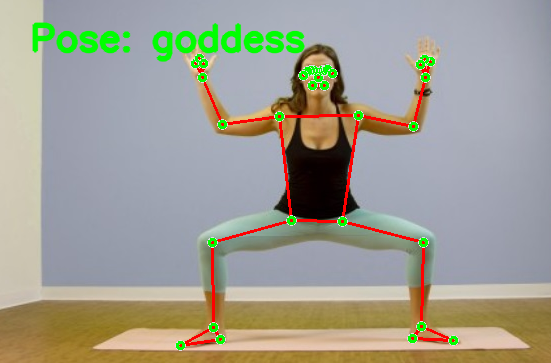

In [ ]:
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
import torch
from IPython.display import Image, display

# Load PyTorch model and label encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier()  # Make sure you have this class defined or imported
model.load_state_dict(torch.load("pose_classifier.pth", map_location=device))
model.to(device)
model.eval()

import pickle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints(image_array):
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        image_rgb = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        if not results.pose_landmarks:
            return None, None
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints, dtype=np.float32).reshape(1, -1), results.pose_landmarks

def draw_pose_landmarks(image_array, landmarks):
    mp_drawing.draw_landmarks(
        image_array, landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))

# Upload image file
uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    keypoints, landmarks = extract_keypoints(img)

    if keypoints is None:
        print("No pose detected in the image.")
        output_path = "output_pose.png"
        cv2.imwrite(output_path, img)
        display(Image(output_path))
        continue

    # Convert keypoints to torch tensor
    input_tensor = torch.tensor(keypoints).to(device)

    # Predict pose class
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]

    # Draw landmarks
    draw_pose_landmarks(img, landmarks)

    # Put text label on the image
    cv2.putText(img, f"Pose: {pred_label}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0, 255, 0), 3, cv2.LINE_AA)

    # Save and display output
    output_path = "output_pose.png"
    cv2.imwrite(output_path, img)

    print(f"✅ Detected Pose: {pred_label}")
    display(Image(output_path))


Saving Screenshot 2025-05-31 091332.png to Screenshot 2025-05-31 091332.png
✅ Detected Pose: downdog


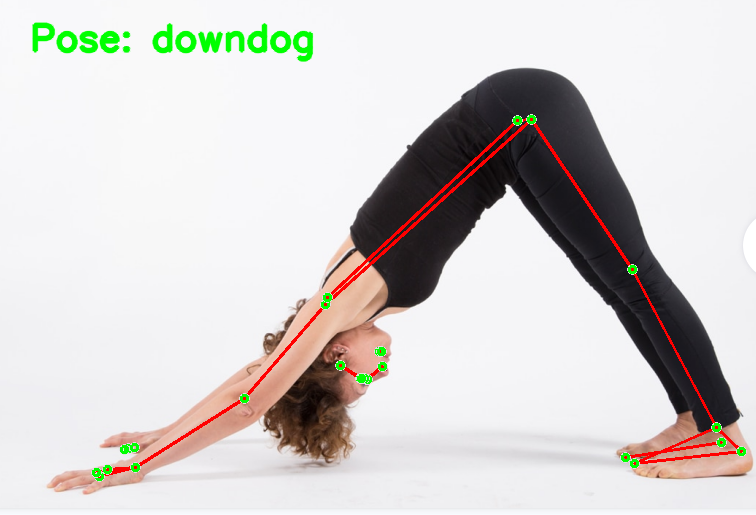

In [ ]:
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
import torch
from IPython.display import Image, display

# Load PyTorch model and label encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier()  # Make sure you have this class defined or imported
model.load_state_dict(torch.load("pose_classifier.pth", map_location=device))
model.to(device)
model.eval()

import pickle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints(image_array):
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        image_rgb = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        if not results.pose_landmarks:
            return None, None
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints, dtype=np.float32).reshape(1, -1), results.pose_landmarks

def draw_pose_landmarks(image_array, landmarks):
    mp_drawing.draw_landmarks(
        image_array, landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))

# Upload image file
uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    keypoints, landmarks = extract_keypoints(img)

    if keypoints is None:
        print("❌ No pose detected in the image.")
        output_path = "output_pose.png"
        cv2.imwrite(output_path, img)
        display(Image(output_path))
        continue

    # Convert keypoints to torch tensor
    input_tensor = torch.tensor(keypoints).to(device)

    # Predict pose class
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]

    # Draw landmarks
    draw_pose_landmarks(img, landmarks)

    # Put text label on the image
    cv2.putText(img, f"Pose: {pred_label}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0, 255, 0), 3, cv2.LINE_AA)

    # Save and display output
    output_path = "output_pose.png"
    cv2.imwrite(output_path, img)

    print(f"✅ Detected Pose: {pred_label}")
    display(Image(output_path))


Saving Screenshot 2025-05-31 091353.png to Screenshot 2025-05-31 091353.png
✅ Detected Pose: plank


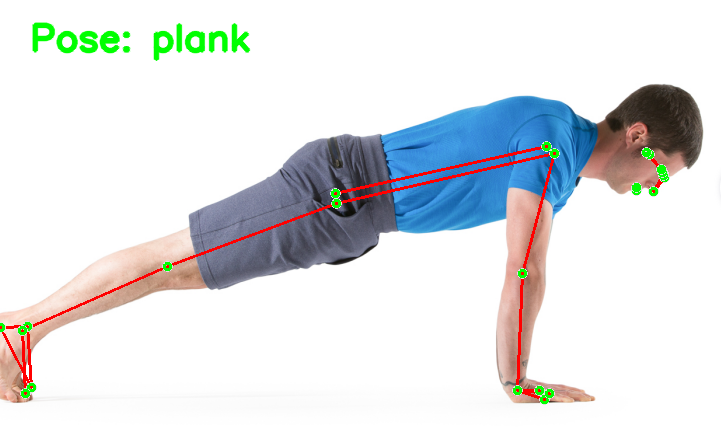

In [ ]:
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
import torch
from IPython.display import Image, display

# Load PyTorch model and label encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier()  # Make sure you have this class defined or imported
model.load_state_dict(torch.load("pose_classifier.pth", map_location=device))
model.to(device)
model.eval()

import pickle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints(image_array):
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        image_rgb = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        if not results.pose_landmarks:
            return None, None
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints, dtype=np.float32).reshape(1, -1), results.pose_landmarks

def draw_pose_landmarks(image_array, landmarks):
    mp_drawing.draw_landmarks(
        image_array, landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))

# Upload image file
uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    keypoints, landmarks = extract_keypoints(img)

    if keypoints is None:
        print("❌ No pose detected in the image.")
        output_path = "output_pose.png"
        cv2.imwrite(output_path, img)
        display(Image(output_path))
        continue

    # Convert keypoints to torch tensor
    input_tensor = torch.tensor(keypoints).to(device)

    # Predict pose class
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]

    # Draw landmarks
    draw_pose_landmarks(img, landmarks)

    # Put text label on the image
    cv2.putText(img, f"Pose: {pred_label}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0, 255, 0), 3, cv2.LINE_AA)

    # Save and display output
    output_path = "output_pose.png"
    cv2.imwrite(output_path, img)

    print(f"✅ Detected Pose: {pred_label}")
    display(Image(output_path))


In [ ]:
# Install required packages if not already installed
!pip install mediapipe

# Imports
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
from IPython.display import Image, display

# Define the PoseClassifier model (Example: 3-layer MLP)
class PoseClassifier(nn.Module):
    def __init__(self, num_classes=82):  # Yoga-82 has 82 classes
        super(PoseClassifier, self).__init__()
        self.fc1 = nn.Linear(132, 128)  # 33 landmarks * 4 (x, y, z, visibility)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Load model and label encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier()
model.load_state_dict(torch.load("pose_classifier.pth", map_location=device))
model.to(device)
model.eval()

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Initialize MediaPipe
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

# Extract 132 pose keypoints
def extract_keypoints(image_array):
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        image_rgb = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        if not results.pose_landmarks:
            return None, None
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints, dtype=np.float32).reshape(1, -1), results.pose_landmarks

# Draw landmarks on the image
def draw_pose_landmarks(image_array, landmarks):
    mp_drawing.draw_landmarks(
        image_array, landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))

# Upload an image
uploaded = files.upload()

for filename in uploaded.keys():
    # Load image
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    # Extract pose keypoints
    keypoints, landmarks = extract_keypoints(img)

    if keypoints is None:
        print("❌ No pose detected in the image.")
        output_path = "output_pose.png"
        cv2.imwrite(output_path, img)
        display(Image(output_path))
        continue

    # Convert to tensor
    input_tensor = torch.tensor(keypoints).to(device)

    # Predict class
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]

    # Draw landmarks
    draw_pose_landmarks(img, landmarks)

    # Add prediction label
    cv2.putText(img, f"Pose: {pred_label}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0, 255, 0), 3, cv2.LINE_AA)

    # Save and show
    output_path = "output_pose.png"
    cv2.imwrite(output_path, img)

    print(f"✅ Detected Pose: {pred_label}")
    display(Image(output_path))


FileNotFoundError: [Errno 2] No such file or directory: 'pose_classifier.pth'

In [ ]:
from google.colab import files
import cv2
import mediapipe as mp
import numpy as np
import torch
from IPython.display import Image, display

# Load PyTorch model and label encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseClassifier()  # Make sure you have this class defined or imported
model.load_state_dict(torch.load("pose_classifier.pth", map_location=device))
model.to(device)
model.eval()

import pickle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def extract_keypoints(image_array):
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        image_rgb = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        if not results.pose_landmarks:
            return None, None
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints, dtype=np.float32).reshape(1, -1), results.pose_landmarks

def draw_pose_landmarks(image_array, landmarks):
    mp_drawing.draw_landmarks(
        image_array, landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2))

# Upload image file
uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    keypoints, landmarks = extract_keypoints(img)

    if keypoints is None:
        print("❌ No pose detected in the image.")
        output_path = "output_pose.png"
        cv2.imwrite(output_path, img)
        display(Image(output_path))
        continue

    # Convert keypoints to torch tensor
    input_tensor = torch.tensor(keypoints).to(device)

    # Predict pose class
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]

    # Draw landmarks
    draw_pose_landmarks(img, landmarks)

    # Put text label on the image
    cv2.putText(img, f"Pose: {pred_label}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0, 255, 0), 3, cv2.LINE_AA)

    # Save and display output
    output_path = "output_pose.png"
    cv2.imwrite(output_path, img)

    print(f"✅ Detected Pose: {pred_label}")
    display(Image(output_path))


NameError: name 'PoseClassifier' is not defined

In [ ]:
!pip install mediapipe